In [1]:
import pandas as pd

df = pd.read_csv('/content/train.csv.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [4]:
# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop Cabin because it has too many missing values
df = df.drop('Cabin', axis=1)

# Fill missing Embarked values with the most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Check missing values again
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


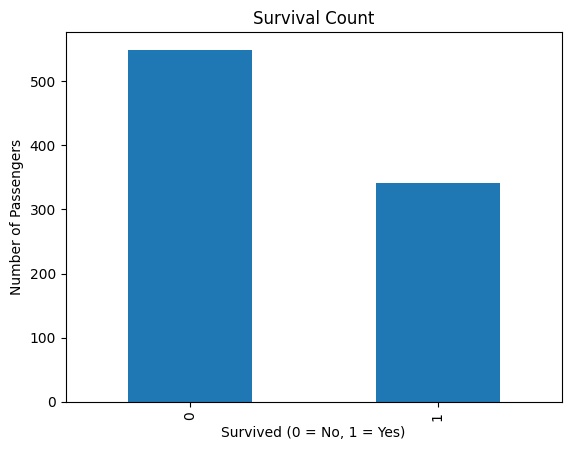

In [6]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind='bar')

plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

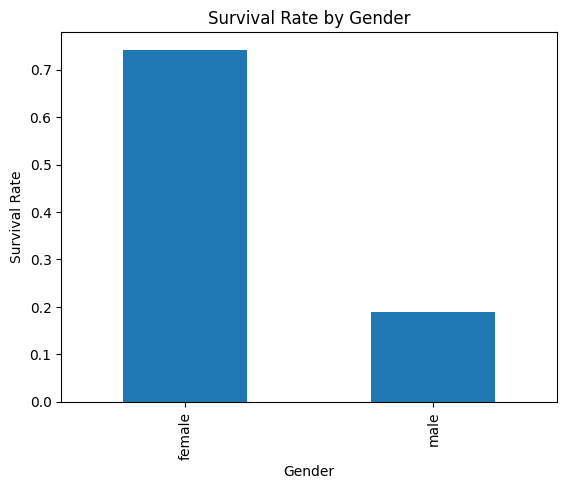

In [7]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

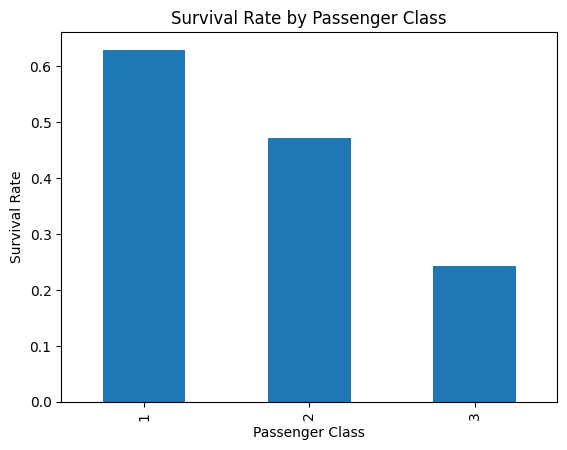

In [8]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

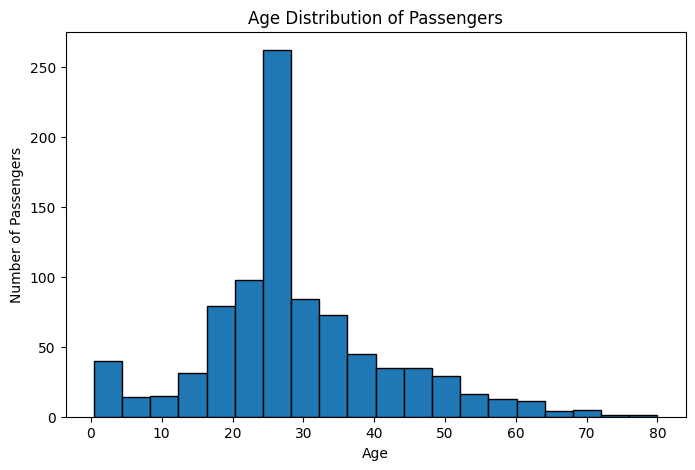

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=20, edgecolor='black')

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

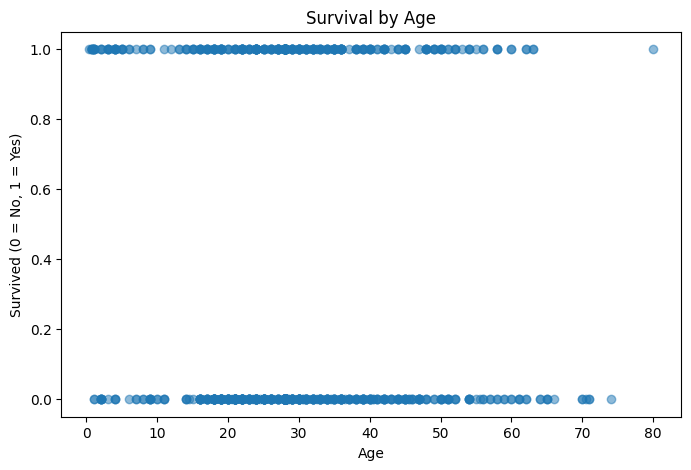

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df['Age'], df['Survived'], alpha=0.5)

plt.title('Survival by Age')
plt.xlabel('Age')
plt.ylabel('Survived (0 = No, 1 = Yes)')

plt.show()

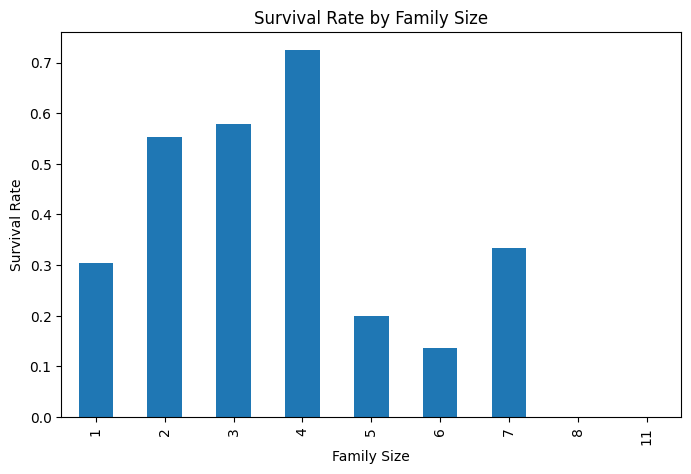

In [11]:
plt.figure(figsize=(8,5))

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df.groupby('FamilySize')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')

plt.show()

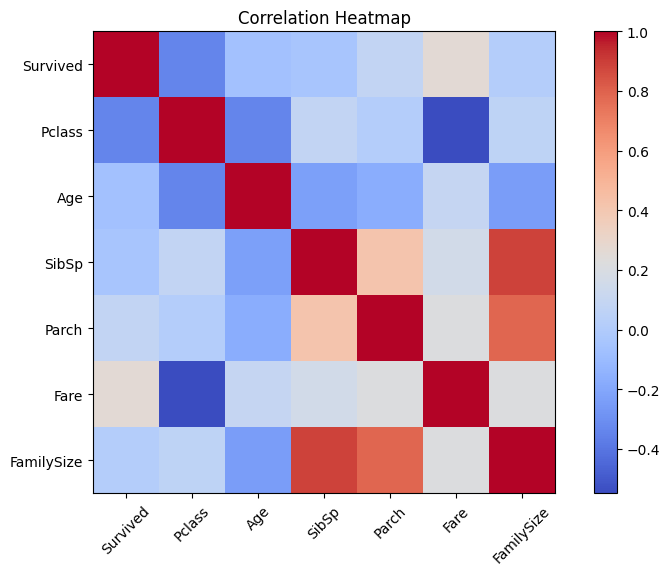

In [12]:
plt.figure(figsize=(10,6))

corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']].corr()

plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Heatmap')

plt.show()

## Key Findings

1. The dataset contains 891 passenger records and 12 columns.

2. There were missing values mainly in the Age, Cabin, and Embarked columns.

3. Missing Age values were filled using the median age, and missing Embarked values were filled using the most common value.

4. Overall, more passengers did not survive than survived.

5. Female passengers had a significantly higher survival rate than male passengers.

6. Passengers in 1st class had the highest survival rate, followed by 2nd class and 3rd class.

7. Most passengers were between 20 and 30 years old.

8. Family size also showed a relationship with survival, with some medium-sized families having better survival rates.

9. The correlation heatmap helped identify relationships between numerical variables such as Pclass, Fare, Age, and Survived.

## Conclusion

The exploratory data analysis shows that factors such as gender, passenger class, age, and family size were associated with survival on the Titanic. Female passengers and passengers in higher classes had noticeably higher survival rates.